In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm.notebook import tqdm

from imports import *
from config import dir_config

In [3]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

# Change this to whichever model was selected as best in 5.21
SELECTED_MODEL = "no_standardization_curr_stim__global_pooled_cv"

GROUPS        = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
GROUP_LABELS  = {"asmHC": "HC", "Tremor_OFF": "Tremor OFF", "Brady_OFF": "Brady OFF",
                 "Tremor_ON": "Tremor ON", "Brady_ON": "Brady ON"}
STATE_COLORS  = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c"]

In [4]:
def align_states(session_weights, ref_weights):
    """Hungarian-algorithm permutation mapping session states → reference states.

    Both arrays are (K, M).  Returns an integer array `perm` of length K such
    that session_weights[i] is matched to reference state perm[i].
    """
    K = session_weights.shape[0]
    cost = np.array([[np.sum((session_weights[i] - ref_weights[j]) ** 2)
                      for j in range(K)] for i in range(K)])
    _, col_ind = linear_sum_assignment(cost)
    # col_ind[i] = reference state that session state i is matched to.
    # We need the inverse: new_order[ref_state] = session_state.
    inv = np.empty_like(col_ind)
    inv[col_ind] = np.arange(K)
    return inv  # apply as: aligned[k] = session[inv[k]]


def load_and_align_group(model_dir, group_name):
    """Load a finetuned bundle, align every session model to the group pooled model.

    Returns a dict with per-session aligned weights, posteriors, and occupancy,
    plus the reference (pooled) weights and the config.
    """
    pkl_path = model_dir / f"{group_name}_final.pkl"
    if not pkl_path.exists():
        print(f"  Missing: {pkl_path}")
        return None

    bundle = pickle.load(open(pkl_path, "rb"))
    config     = bundle["config"]
    ref_model  = bundle["model"]["pooled"]
    ref_w      = -ref_model.observations.params[:, 0, :]  # (K, M)

    session_weights   = {}
    session_posteriors = {}
    session_occupancy  = {}

    for session_id, sess_model in bundle["model"]["models"].items():
        sess_w = -sess_model.observations.params[:, 0, :]  # (K, M)
        perm   = align_states(sess_w, ref_w)               # length-K permutation

        session_weights[session_id] = sess_w[perm]         # (K, M)

        # Forward-backward over the full session sequence
        glm_df     = bundle["data"][session_id]
        all_data   = glm_df["choices"].values.astype(int).reshape(-1, 1)
        all_inputs = glm_df[config["model_features"]].values.astype(np.float64)
        all_masks  = glm_df["mask"].values.astype(bool).reshape(-1, 1)

        post = sess_model.expected_states(
            data=all_data, input=all_inputs, mask=all_masks
        )[0]  # (T, K)
        aligned_post = post[:, perm]                       # (T, K)
        session_posteriors[session_id] = aligned_post

        valid = all_masks[:, 0]
        session_occupancy[session_id] = aligned_post[valid].mean(axis=0)  # (K,)

    return {
        "config":             config,
        "best_k":             bundle["best_k"],
        "ref_weights":        ref_w,
        "session_weights":    session_weights,    # session_id → (K, M)
        "session_posteriors": session_posteriors, # session_id → (T, K)
        "session_occupancy":  session_occupancy,  # session_id → (K,)
    }

In [5]:
model_dir  = glm_hmm_dir / SELECTED_MODEL
group_data = {}

for group in GROUPS:
    data = load_and_align_group(model_dir, group)
    if data is not None:
        group_data[group] = data
        print(f"{group:12s}  K={data['best_k']}  n_sessions={len(data['session_weights'])}")

asmHC         K=3  n_sessions=18
Tremor_OFF    K=2  n_sessions=11
Brady_OFF     K=1  n_sessions=10
Tremor_ON     K=3  n_sessions=11
Brady_ON      K=2  n_sessions=10


In [6]:
def plot_group(ax_psych, ax_weights, ax_occ, group, gdata):
    K       = gdata["best_k"]
    config  = gdata["config"]
    feats   = config["model_features"]
    colors  = STATE_COLORS[:K]

    # ── stack per-session arrays ──────────────────────────────────────────────
    all_weights   = np.stack(list(gdata["session_weights"].values()))   # (S, K, M)
    all_occupancy = np.stack(list(gdata["session_occupancy"].values()))  # (S, K)
    S = all_weights.shape[0]

    mean_w   = all_weights.mean(axis=0)                     # (K, M)
    sem_w    = all_weights.std(axis=0) / np.sqrt(S)         # (K, M)
    mean_occ = all_occupancy.mean(axis=0)                   # (K,)
    sem_occ  = all_occupancy.std(axis=0) / np.sqrt(S)       # (K,)

    # ── psychometric: sigmoid from mean weights, other features fixed at 0 ──
    stim_idx = feats.index("stimulus") if "stimulus" in feats else 0
    bias_idx = feats.index("bias") if "bias" in feats else None
    stim_range = np.linspace(-1, 1, 200)

    for k in range(K):
        logit = mean_w[k, stim_idx] * stim_range
        if bias_idx is not None:
            logit = logit + mean_w[k, bias_idx]
        ax_psych.plot(stim_range * 100, 1 / (1 + np.exp(-logit)),
                      color=colors[k], lw=2, label=f"State {k+1}")
    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1),
                 title=GROUP_LABELS.get(group, group))
    ax_psych.legend(fontsize=8)

    # ── GLM weights: mean ± SEM per state ────────────────────────────────────
    x = np.arange(len(feats))
    for k in range(K):
        ax_weights.errorbar(x, mean_w[k], yerr=sem_w[k],
                            color=colors[k], marker="o", lw=1.5, capsize=3,
                            label=f"State {k+1}")
    ax_weights.axhline(0, color="k", ls="--", lw=0.8)
    ax_weights.set_xticks(x)
    ax_weights.set_xticklabels(feats, rotation=20, ha="right", fontsize=9)
    ax_weights.set(ylabel="GLM weight", title="Weights (mean ± SEM)")
    ax_weights.legend(fontsize=8)

    # ── state occupancy: bar chart mean ± SEM ────────────────────────────────
    xk = np.arange(K)
    ax_occ.bar(xk, mean_occ, color=colors, alpha=0.8, yerr=sem_occ,
               capsize=4, error_kw={"elinewidth": 1.5})
    # scatter individual session points
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S),
                       all_occupancy[:, k], color=colors[k],
                       s=12, alpha=0.6, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([f"State {k+1}" for k in range(K)])
    ax_occ.set(ylabel="Fraction of trials", ylim=(0, 1),
               title="State occupancy")

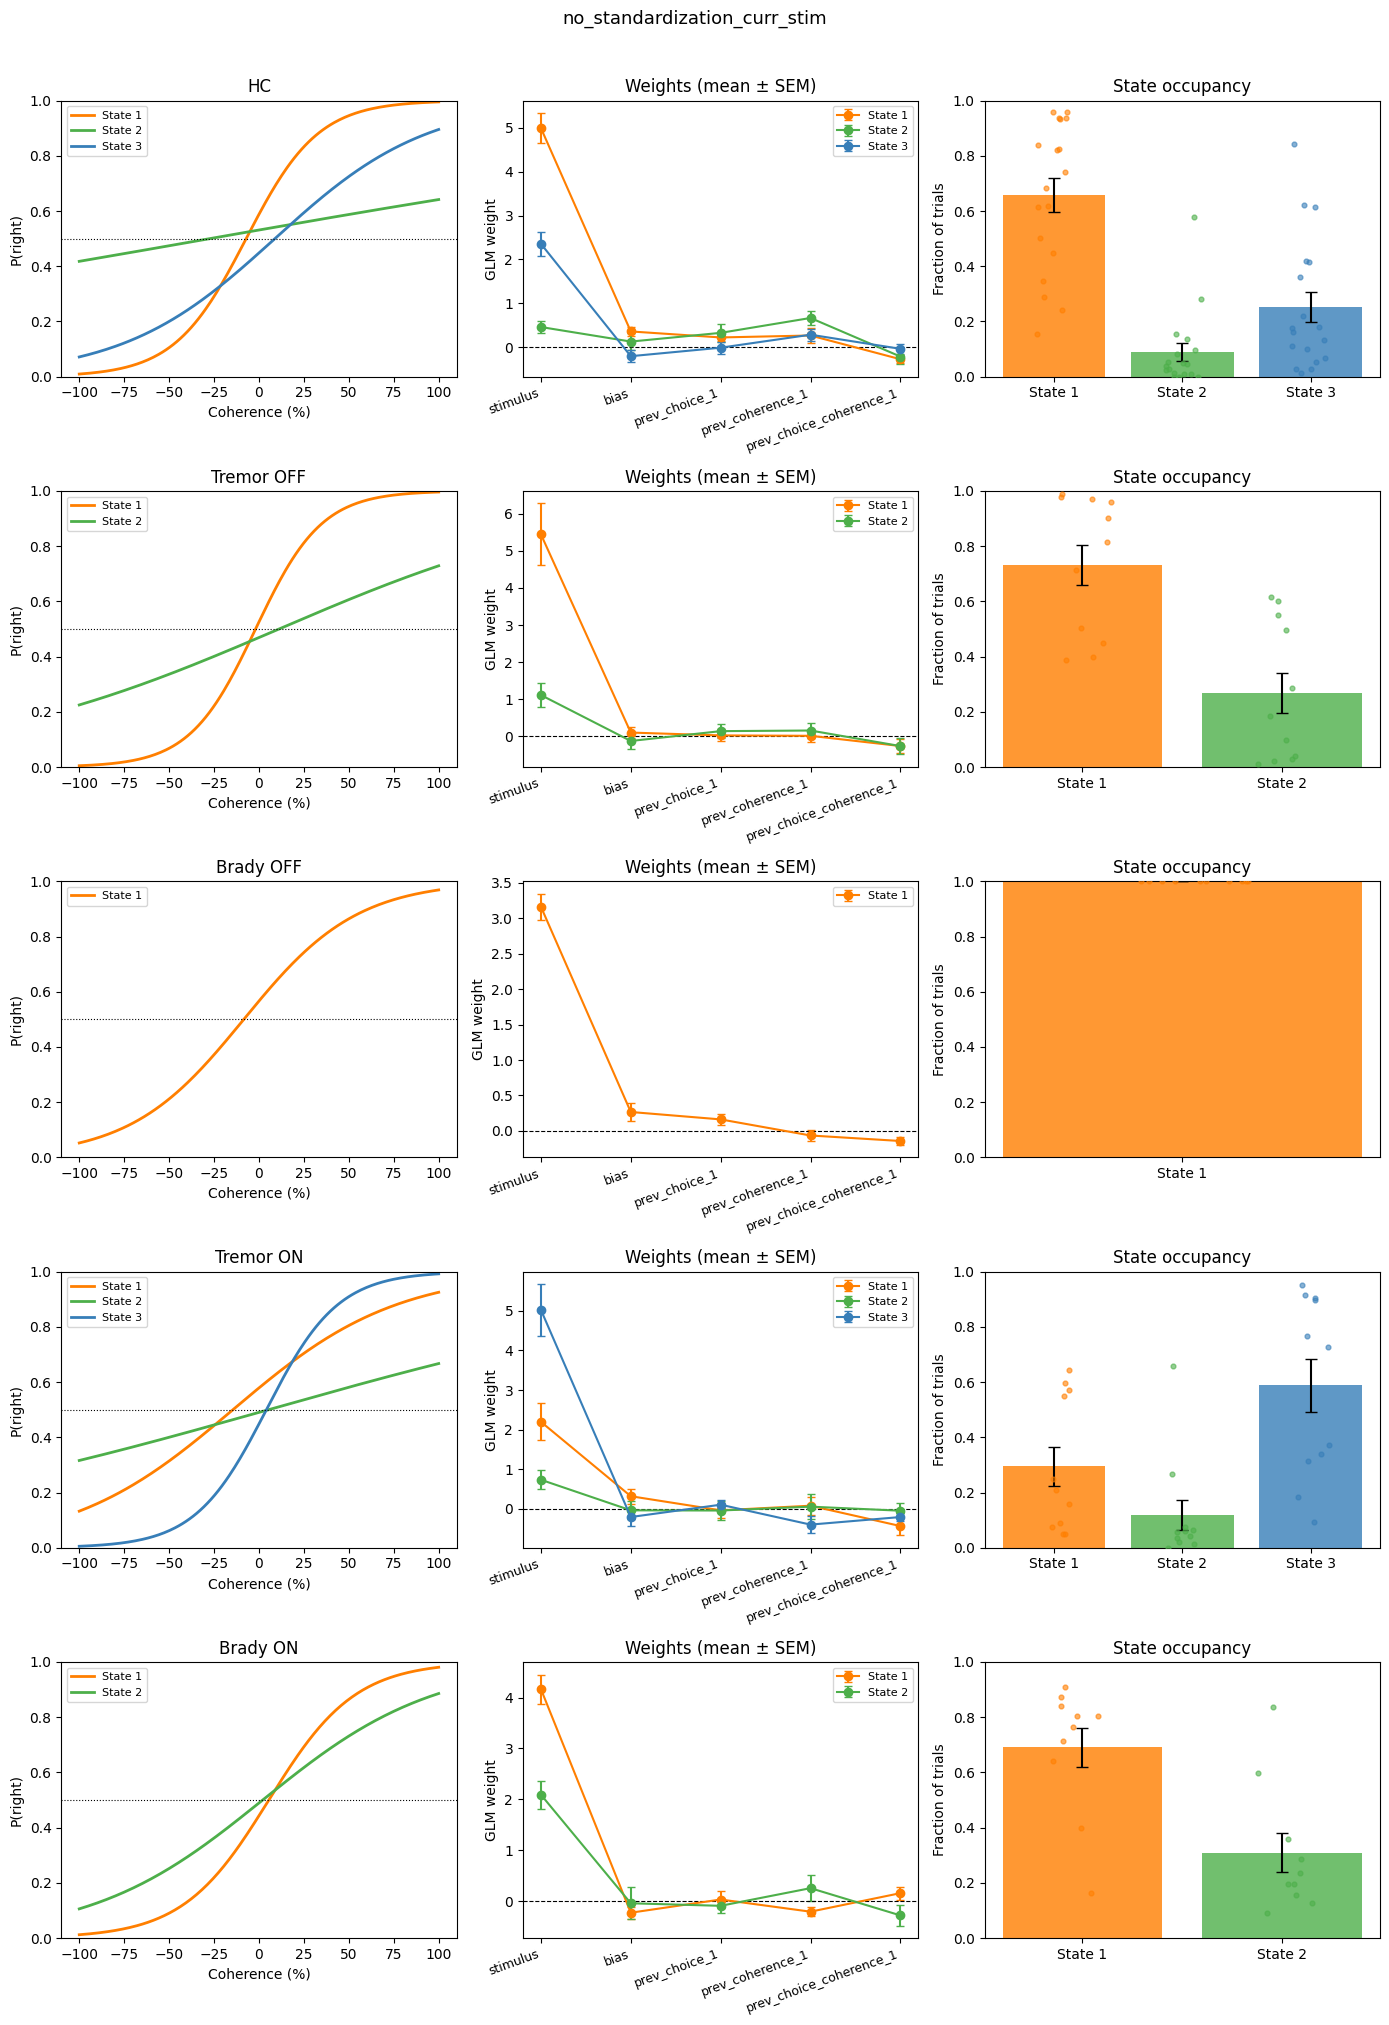

In [7]:
n_groups = len(group_data)
fig, axes = plt.subplots(n_groups, 3, figsize=(14, 4 * n_groups))
if n_groups == 1:
    axes = axes[np.newaxis, :]

for row, group in enumerate(GROUPS):
    if group not in group_data:
        continue
    plot_group(axes[row, 0], axes[row, 1], axes[row, 2], group, group_data[group])

plt.suptitle(SELECTED_MODEL.replace("__global_pooled_cv", ""), fontsize=13, y=1.01)
plt.tight_layout()
plt.show()